In [56]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, learning_curve,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)

import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("xgboost not installed - Section 14 will be skipped gracefully.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

print(f"XGBoost available: {XGBOOST_AVAILABLE}")

XGBoost available: True


In [57]:
df = pd.read_csv("Cancer_Data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [58]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [59]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (569, 33)


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [61]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012


In [62]:
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().sum() / len(df) * 100).round(2),
})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
missing_table

Duplicate rows: 0

Data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst       

,Missing Count,Missing %
Unnamed: 32,569,100.0


In [63]:
print(df.isna().sum().sort_values(ascending=False).head())


Unnamed: 32                569
compactness_se               0
fractal_dimension_worst      0
symmetry_worst               0
concave points_worst         0
dtype: int64


In [64]:
df = df.drop(columns=['Unnamed: 32', 'id'])
print( df.duplicated().sum())
print( df.shape)
df.head()




0
(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [65]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

print(df['diagnosis'].value_counts())
df['diagnosis'].head()


diagnosis
0    357
1    212
Name: count, dtype: int64


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

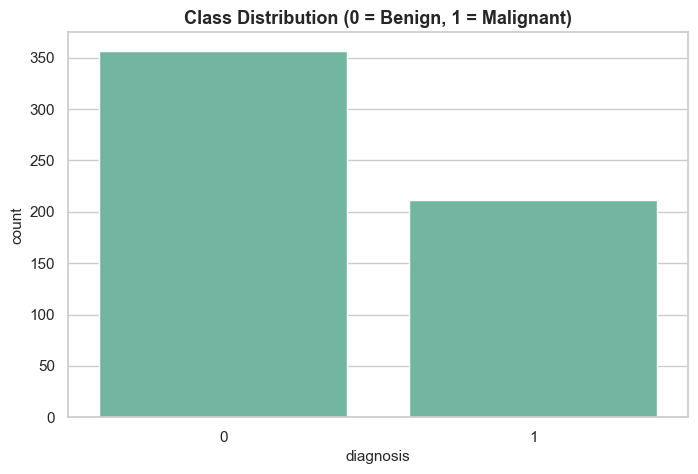

diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


In [66]:
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (0 = Benign, 1 = Malignant)')
plt.show()

print(df['diagnosis'].value_counts(normalize=True) * 100)


In [67]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

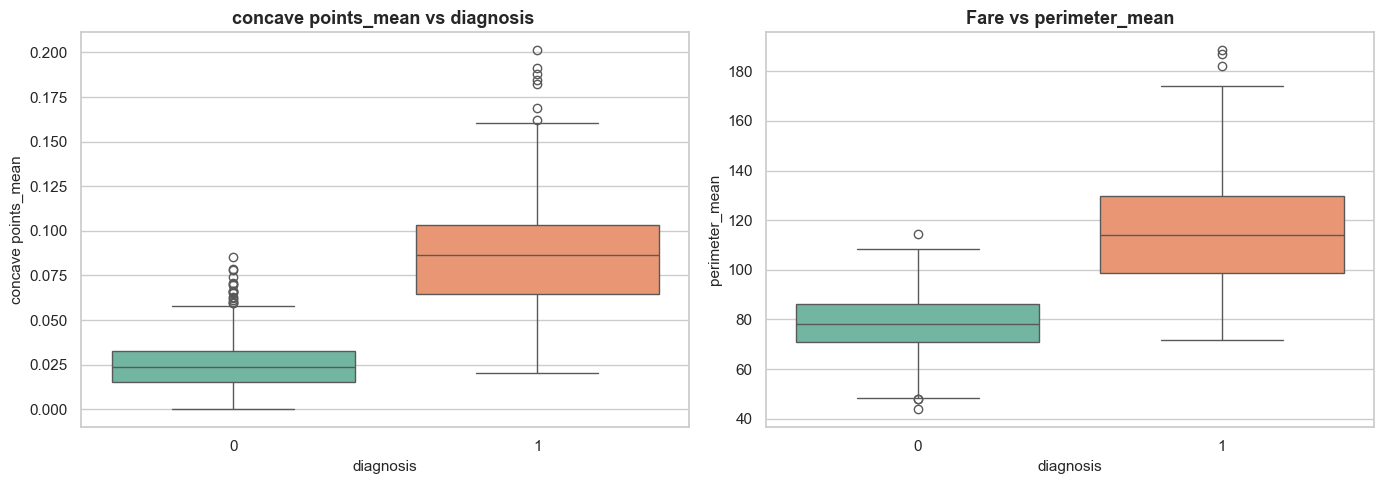

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="diagnosis", y="concave points_mean", ax=axes[0], hue="diagnosis",
            palette="Set2", legend=False)
axes[0].set_title("concave points_mean vs diagnosis ")

sns.boxplot(data=df, x="diagnosis", y="perimeter_mean", ax=axes[1], hue="diagnosis",
            palette="Set2", legend=False)
axes[1].set_title("Fare vs perimeter_mean")
plt.tight_layout()
plt.show()

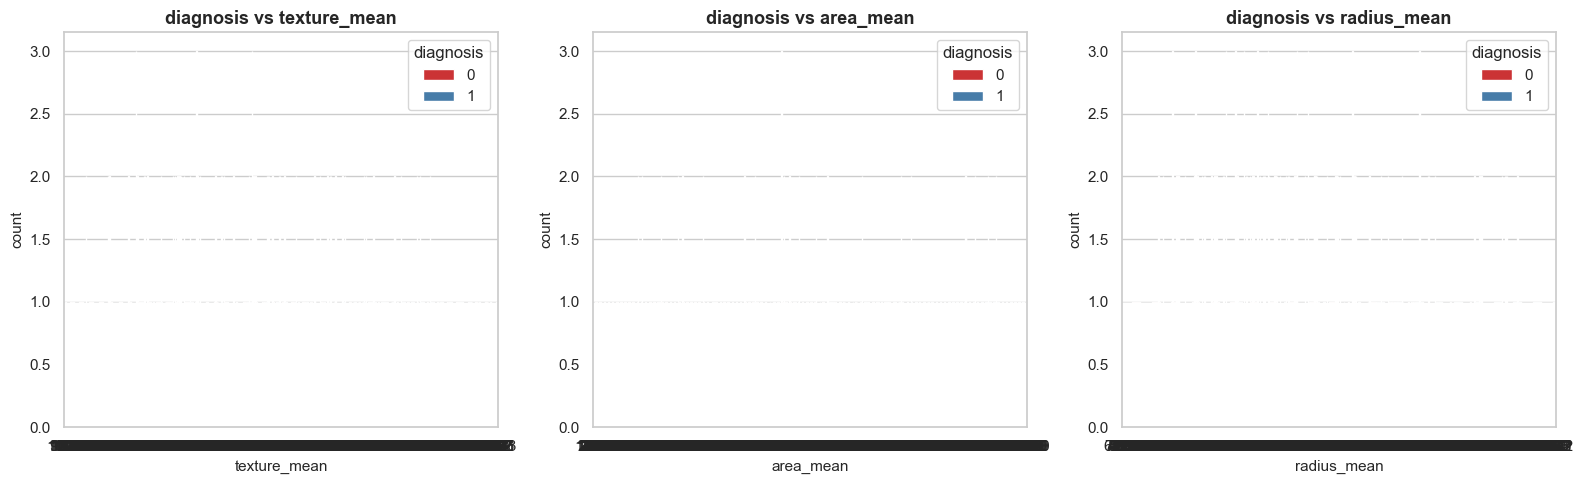

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x="texture_mean", hue="diagnosis", ax=axes[0], palette="Set1")
axes[0].set_title("diagnosis vs texture_mean")

sns.countplot(data=df, x="area_mean", hue="diagnosis", ax=axes[1], palette="Set1")
axes[1].set_title("diagnosis vs area_mean")

sns.countplot(data=df, x="radius_mean", hue="diagnosis", ax=axes[2], palette="Set1")
axes[2].set_title("diagnosis vs radius_mean")
plt.tight_layout()
plt.show()

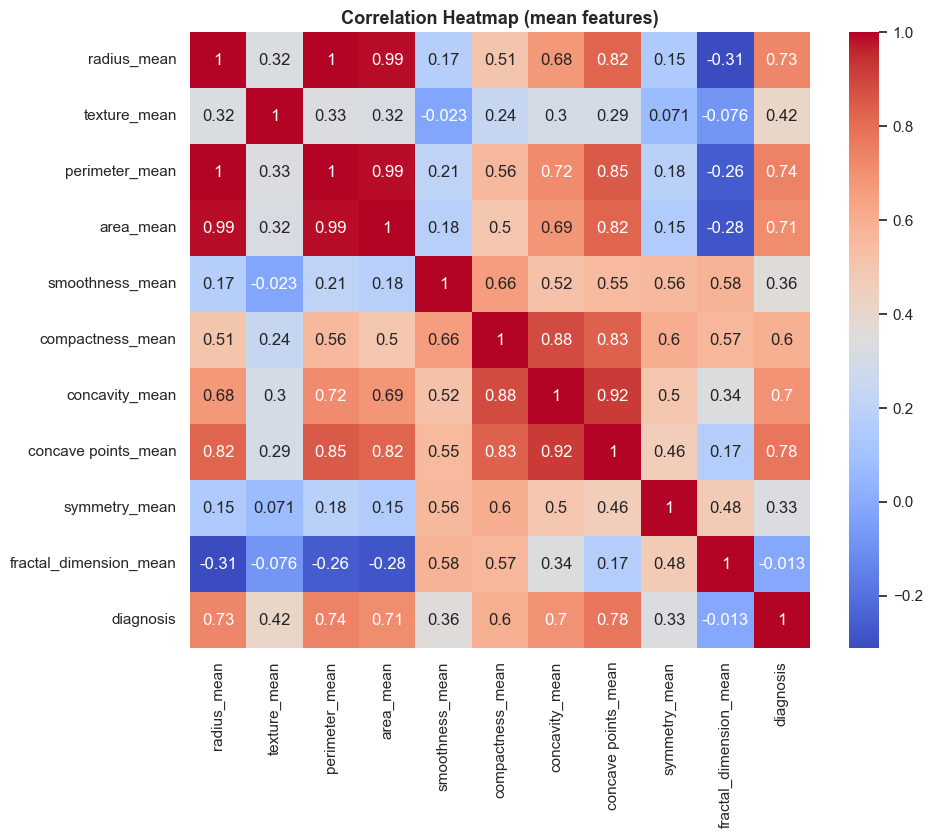

In [70]:
mean_cols = [c for c in df.columns if '_mean' in c] + ['diagnosis']
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (mean features)')
plt.show()


In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (455, 30) | X_test: (114, 30)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print( X_train.iloc[0].values[:5])
print(X_train_scaled[0][:5])


[1.602e+01 2.324e+01 1.027e+02 7.978e+02 8.206e-02]
[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]


In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


Accuracy: 0.9649


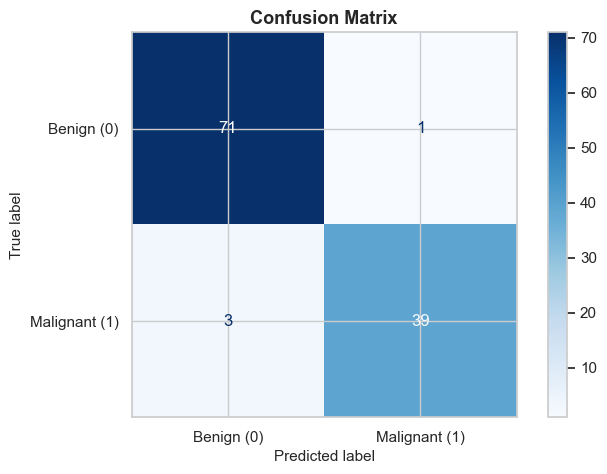

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC: 0.9960


In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benign (0)', 'Malignant (1)']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.4f}")


In [75]:
tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)

print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves: {tree_model.get_n_leaves()}")
print(f"Train accuracy: {accuracy_score(y_train, tree_model.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, tree_model.predict(X_test)):.4f}")

Tree depth: 8
Number of leaves: 24
Train accuracy: 1.0000
Test accuracy:  0.9298


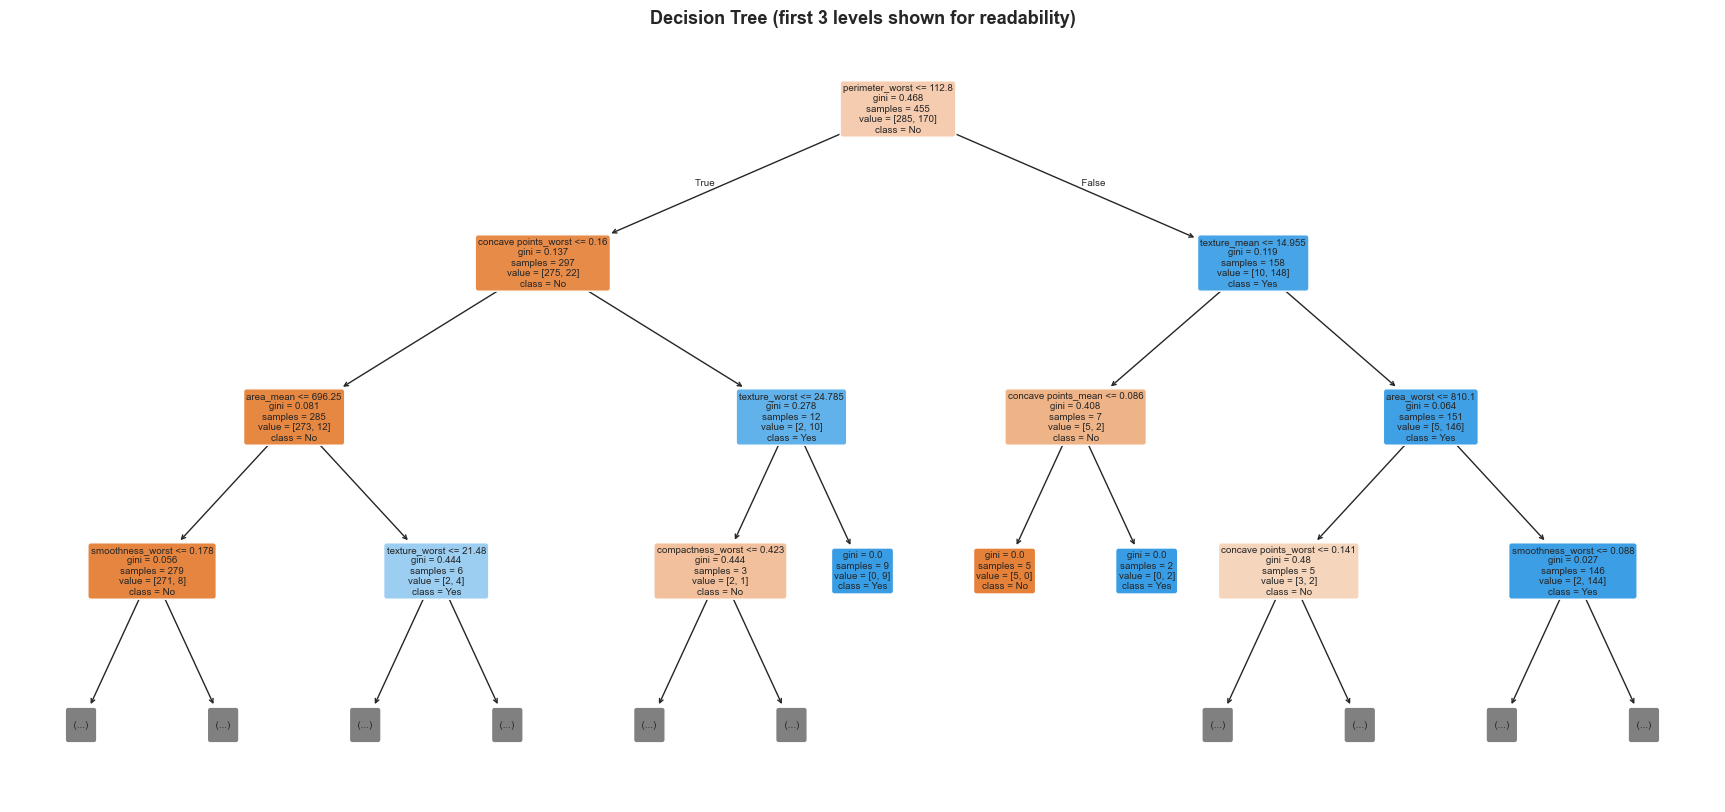

In [76]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model, feature_names=X_train.columns, class_names=["No", "Yes"],
    filled=True, rounded=True, fontsize=7, max_depth=3,
)
plt.title("Decision Tree (first 3 levels shown for readability)")
plt.show()

In [77]:
importance_table = (
    pd.Series(tree_model.feature_importances_, index=X_train.columns, name="Importance")
    .sort_values(ascending=False)
)
importance_table.to_frame()

,Importance
perimeter_worst,0.727477
concave points_worst,0.078970
smoothness_worst,0.040833
texture_mean,0.037871
texture_worst,0.022545
area_mean,0.022452
radius_worst,0.017530
area_worst,0.015606
concave points_mean,0.013416
concavity_se,0.007043


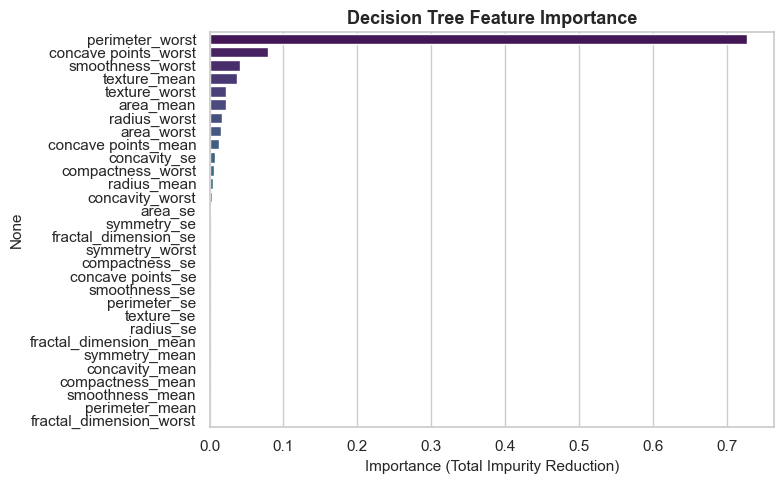

In [78]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importance_table.values, y=importance_table.index, hue=importance_table.index,
            palette="viridis", legend=False)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance (Total Impurity Reduction)")
plt.tight_layout()
plt.show()

In [79]:
forest_model = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, oob_score=True
)
forest_model.fit(X_train, y_train)

single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
single_tree.fit(X_train, y_train)

forest_vs_tree = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [
        accuracy_score(y_train, single_tree.predict(X_train)),
        accuracy_score(y_train, forest_model.predict(X_train)),
    ],
    "Test Accuracy": [
        accuracy_score(y_test, single_tree.predict(X_test)),
        accuracy_score(y_test, forest_model.predict(X_test)),
    ],
}).round(4)

print(f"Number of trees: {forest_model.n_estimators}")
print(f"OOB Score: {forest_model.oob_score_:.4f}")
forest_vs_tree

Number of trees: 200
OOB Score: 0.9538


,Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.0,0.9298
1,Random Forest,1.0,0.9649


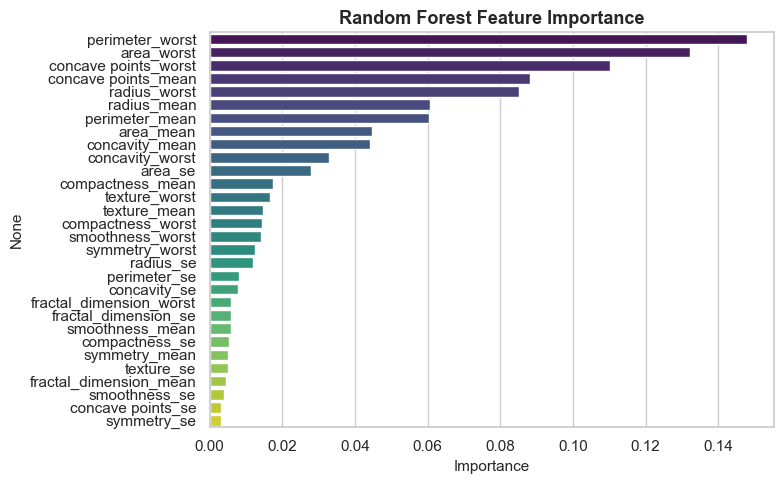

In [80]:
rf_importance = (
    pd.Series(forest_model.feature_importances_, index=X_train.columns, name="Importance")
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importance.values, y=rf_importance.index, hue=rf_importance.index,
            palette="viridis", legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [101]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [102]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [103]:
y_pred = model.predict(X_test)

In [104]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [105]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



[[72  0]
 [ 4 38]]


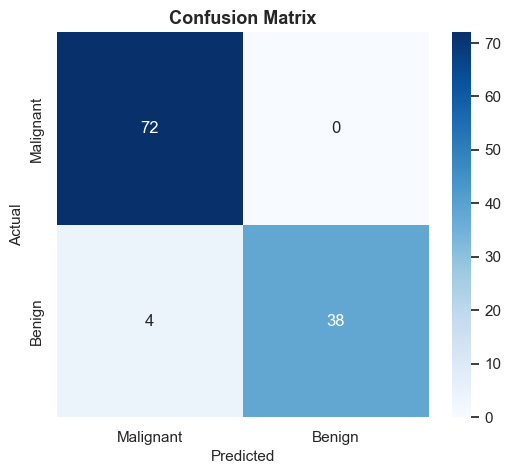

In [106]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [107]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

perimeter_worst         0.278365
radius_worst            0.251420
concave points_mean     0.129637
concave points_worst    0.080885
concavity_mean          0.026811
concavity_worst         0.025531
area_mean               0.020768
texture_mean            0.019833
texture_worst           0.017856
concavity_se            0.016952
dtype: float32

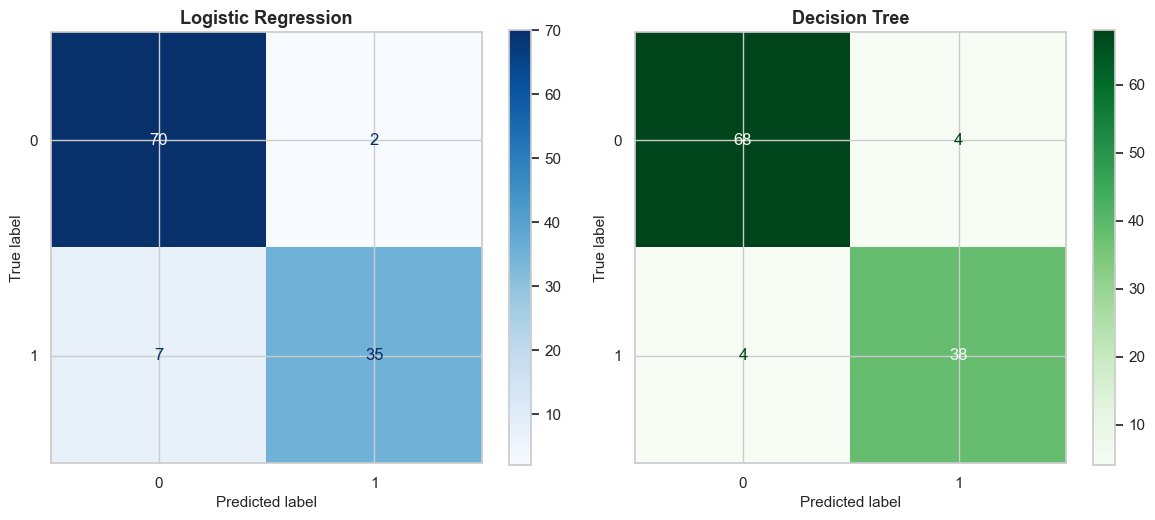

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

log_model = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)

log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens",
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()

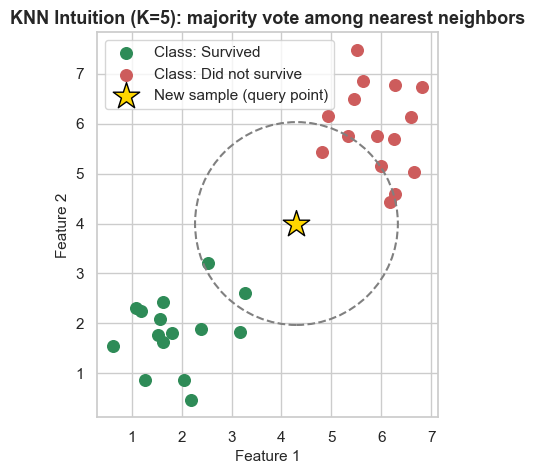

In [ ]:
np.random.seed(RANDOM_STATE)

# Synthetic 2D illustration (not the real dataset) purely to visualize the concept
class_a = np.random.normal(loc=(2, 2), scale=0.8, size=(15, 2))   
class_b = np.random.normal(loc=(6, 6), scale=0.8, size=(15, 2))   
query_point = np.array([4.3, 4.0])

fig, ax = plt.subplots()
ax.scatter(class_a[:, 0], class_a[:, 1], color="seagreen", label="Class: Survived", s=70)
ax.scatter(class_b[:, 0], class_b[:, 1], color="indianred", label="Class: Did not survive", s=70)
ax.scatter(*query_point, color="gold", edgecolor="black", marker="*", s=400, label="New sample (query point)")

# draw circle around the K=5 nearest neighbors
all_points = np.vstack([class_a, class_b])
dists = np.linalg.norm(all_points - query_point, axis=1)
k = 5
nearest_idx = np.argsort(dists)[:k]
radius = dists[nearest_idx].max()
circle = plt.Circle(query_point, radius, color="gray", fill=False, linestyle="--", linewidth=1.5)
ax.add_patch(circle)

ax.set_title(f"KNN Intuition (K={k}): majority vote among nearest neighbors")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.set_aspect("equal")
plt.show()

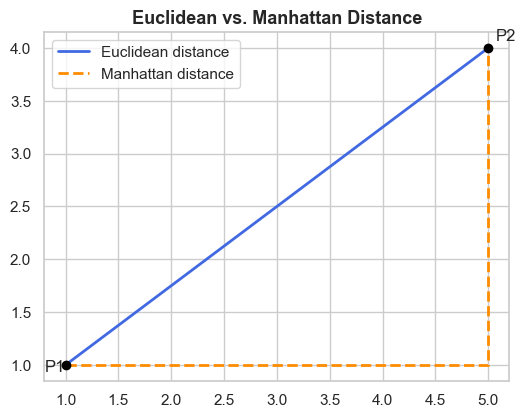

Euclidean distance: 5.00
Manhattan distance: 7.00


In [83]:
p1 = np.array([1, 1])
p2 = np.array([5, 4])

fig, ax = plt.subplots(figsize=(6, 6))

# Euclidean: straight line
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="royalblue", linewidth=2, label="Euclidean distance")

# Manhattan: grid path
ax.plot([p1[0], p2[0], p2[0]], [p1[1], p1[1], p2[1]], color="darkorange", linewidth=2, linestyle="--", label="Manhattan distance")

ax.scatter(*p1, color="black", zorder=5)
ax.scatter(*p2, color="black", zorder=5)
ax.annotate("P1", p1, textcoords="offset points", xytext=(-15, -5))
ax.annotate("P2", p2, textcoords="offset points", xytext=(5, 5))

ax.set_title("Euclidean vs. Manhattan Distance")
ax.legend()
ax.set_aspect("equal")
plt.show()

euclidean = np.linalg.norm(p2 - p1)
manhattan = np.sum(np.abs(p2 - p1))
print(f"Euclidean distance: {euclidean:.2f}")
print(f"Manhattan distance: {manhattan:.2f}")

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


In [86]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions: ", y_pred[:10])
print("First 10 actual labels:", y_test.values[:10])

First 10 predictions:  [0 1 0 0 0 0 1 0 0 0]
First 10 actual labels: [0 1 0 1 0 0 1 0 0 0]


In [87]:
def print_metrics(y_true, y_pred, y_proba=None, model_name="Model"):
    """Reusable helper to print a standard classification metrics summary."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC AUC  : {auc:.4f}")
        return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

baseline_metrics = print_metrics(y_test, y_pred, y_proba, model_name="KNN (K=5, baseline)")

--- KNN (K=5, baseline) ---
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383
ROC AUC  : 0.9823


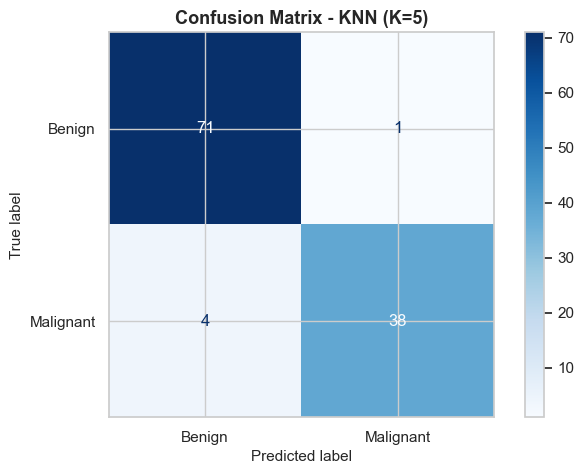

Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN (K=5)")
plt.show()

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))

In [90]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

scores = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

print(scores)

[0.8947368421052632, 0.9122807017543859, 0.9210526315789473, 0.9210526315789473, 0.9122807017543859, 0.9210526315789473, 0.9122807017543859, 0.9122807017543859, 0.9210526315789473, 0.9210526315789473, 0.9473684210526315, 0.9298245614035088, 0.9385964912280702, 0.9385964912280702, 0.9298245614035088, 0.9385964912280702, 0.9385964912280702, 0.9298245614035088, 0.9385964912280702, 0.9210526315789473]


In [98]:
best_k = np.argmax(scores) + 1

print(best_k)

11


In [99]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train, y_train)

,n_neighbors,np.int64(11)
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


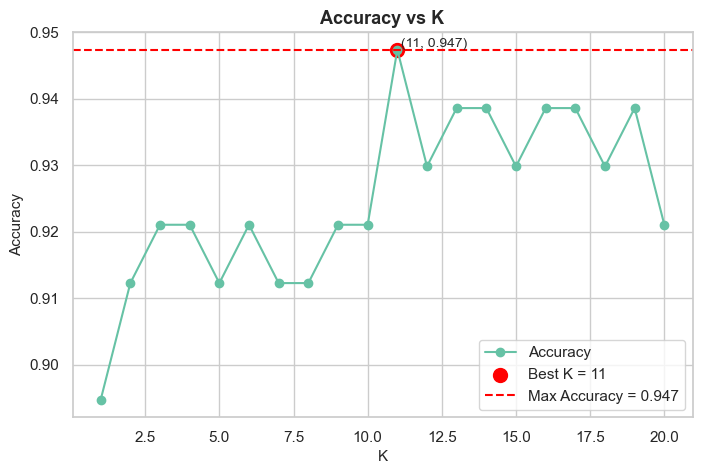

In [97]:
import matplotlib.pyplot as plt
import numpy as np

best_accuracy = max(scores)
best_k = np.argmax(scores) + 1   

plt.figure(figsize=(8,5))

plt.plot(range(1,21), scores, marker='o', label='Accuracy')

plt.scatter(best_k, best_accuracy, color='red', s=100,
            label=f'Best K = {best_k}')

plt.axhline(y=best_accuracy, color='red', linestyle='--',
            label=f'Max Accuracy = {best_accuracy:.3f}')

plt.text(best_k, best_accuracy,
         f' ({best_k}, {best_accuracy:.3f})',
         fontsize=10, va='bottom')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.legend()

plt.show()

In [93]:
new_sample = scaler.transform(X.iloc[[0]])
prediction = model.predict(new_sample)
print(prediction)

[0]


In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.921053
1        Decision Tree  0.929825
2                  KNN  0.912281


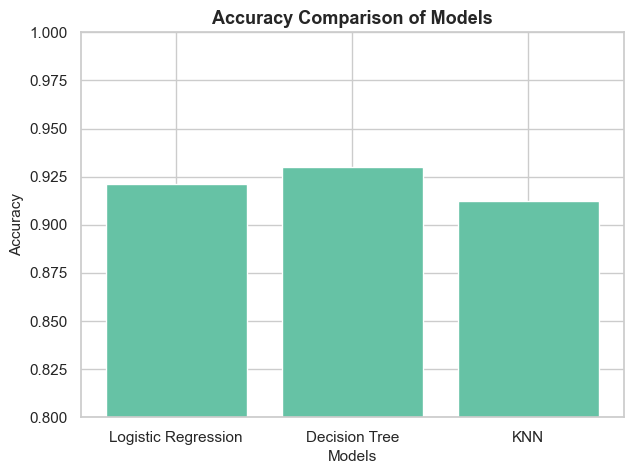

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

In [109]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [110]:

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [111]:
model = GaussianNB()

In [112]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [113]:
y_pred = model.predict(X_test)

In [114]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9210526315789473


In [115]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



In [116]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[69  3]
 [ 6 36]]


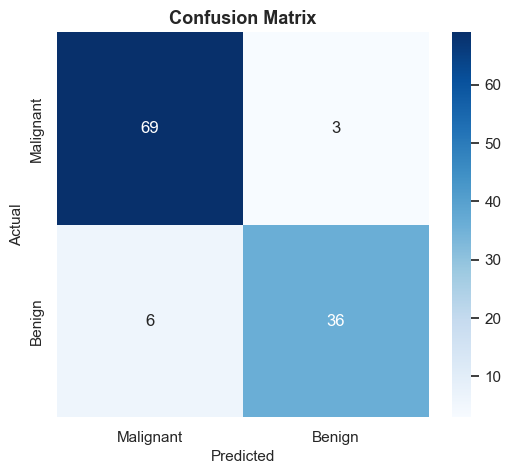

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [118]:
new_patient = X.iloc[[0]]
new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)


[1]


In [119]:
prob = model.predict_proba(new_patient)

print(prob)

[[1.02698982e-154 1.00000000e+000]]


In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy
2        Random Forest  0.973684
0  Logistic Regression  0.964912
3              XGBoost  0.964912
4                  KNN  0.956140
1        Decision Tree  0.929825
5          Naive Bayes  0.921053


In [123]:
new_patient = pd.DataFrame({
    "radius_mean":[14.5],
    "texture_mean":[20.1],
    "perimeter_mean":[95.4],
    "area_mean":[650],
    "smoothness_mean":[0.10],
    "compactness_mean":[0.12],
    "concavity_mean":[0.08],
    "concave points_mean":[0.05],
    "symmetry_mean":[0.18],
    "fractal_dimension_mean":[0.06],

    "radius_se":[0.40],
    "texture_se":[1.20],
    "perimeter_se":[2.90],
    "area_se":[38],
    "smoothness_se":[0.005],
    "compactness_se":[0.020],
    "concavity_se":[0.025],
    "concave points_se":[0.010],
    "symmetry_se":[0.018],
    "fractal_dimension_se":[0.003],

    "radius_worst":[17.2],
    "texture_worst":[26.5],
    "perimeter_worst":[110],
    "area_worst":[850],
    "smoothness_worst":[0.14],
    "compactness_worst":[0.25],
    "concavity_worst":[0.30],
    "concave points_worst":[0.12],
    "symmetry_worst":[0.28],
    "fractal_dimension_worst":[0.09]
})
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)
if prediction[0] == 1:
    print(" Prediction: Malignant (Cancer)")
else:
    print(" Prediction: Benign (No Cancer)")
    
prob = model.predict_proba(new_patient_scaled)

print(f"Probability of Malignant: {prob[0][1]*100:.2f}%")
print(f"Probability of Benign: {prob[0][0]*100:.2f}%")

 Prediction: Benign (No Cancer)
Probability of Malignant: 0.23%
Probability of Benign: 99.77%
